In [2]:
import sys
import os
my_path = os.path.dirname(os.getcwd())
sys.path.append(my_path)

# from prev_ob_models.Doxey2022.isolated_cells import *
import prev_ob_models.Doxey2022.isolated_cells as ic
from neuron import h
import matplotlib.pyplot as plt

from lfp_analysis import *

--No graphics will be displayed.


In [3]:
if not os.path.isdir('../prev_ob_models/Doxey2022/Mechanisms/x86_64'):
    os.system('python ../prev_ob_models/Doxey2022/compile_mechs.py')
else:
    print('Mechanisms already compiled')
# ! python ../prev_ob_models/Doxey2022/compile_mechs.py

Mechanisms already compiled


## Load cells

In [4]:
mc_cells = [ic.MC1(), ic.MC2(), ic.MC3(), ic.MC4(), ic.MC5()]
tc_cells = [ic.TC1(), ic.TC2(), ic.TC3(), ic.TC4(), ic.TC5()]
gc_cells = [ic.GC1(), ic.GC2(), ic.GC3(), ic.GC4(), ic.GC5()]
# gc_cell = ic.GC3()

Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.


## Initialize h

In [5]:
h.cvode_active(0)
delay = 200
dur = 700
h.tstop = 1000
h.celsius = 35
h.steps_per_ms = 10
h.dt = 1.0 / h.steps_per_ms

## Mitral Cells

In [6]:
mc_amps = [0.25, 0, -0.1]
num_mc_cells = len(mc_cells)

In [7]:
def add_background_input(cell, amp):
    """
    Adds a small injected current to the soma of all cells for the duration of simulation

    """

    assert hasattr(cell, 'soma'), "Neuron does not have a soma segment."
    print(f'injecting current to cell {cell}')  
    stim = h.IClamp(0.5, sec=cell.soma)
    stim.delay = delay
    stim.dur = 1750   # 1750 ms
    stim.amp = amp

    t = h.Vector().record(h._ref_t)
    v = h.Vector().record(cell.soma(0.5)._ref_v)
    iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
    iK = h.Vector().record(cell.soma(0.5)._ref_ik)
    iCa = h.Vector().record(cell.soma(0.5)._ref_ica)
    
    h.run() # has to be within the function to work

    return t, v, iNa, iK, iCa
    

injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC1 object at 0x7f8cdd462850>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC1 object at 0x7f8cdd462850>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC1 object at 0x7f8cdd462850>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC2 object at 0x7f8e582f83d0>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC2 object at 0x7f8e582f83d0>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC2 object at 0x7f8e582f83d0>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC3 object at 0x7f8e58397950>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC3 object at 0x7f8e58397950>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC3 object at 0x7f8e58397950>
injecting current to cell <prev_ob_models.Doxey2022.isolated_cells.MC4 object at 0x7f8ce2a30790>
injecting current to cell <pre

Text(0, 0.5, 'Ca current (mA/cm2)')

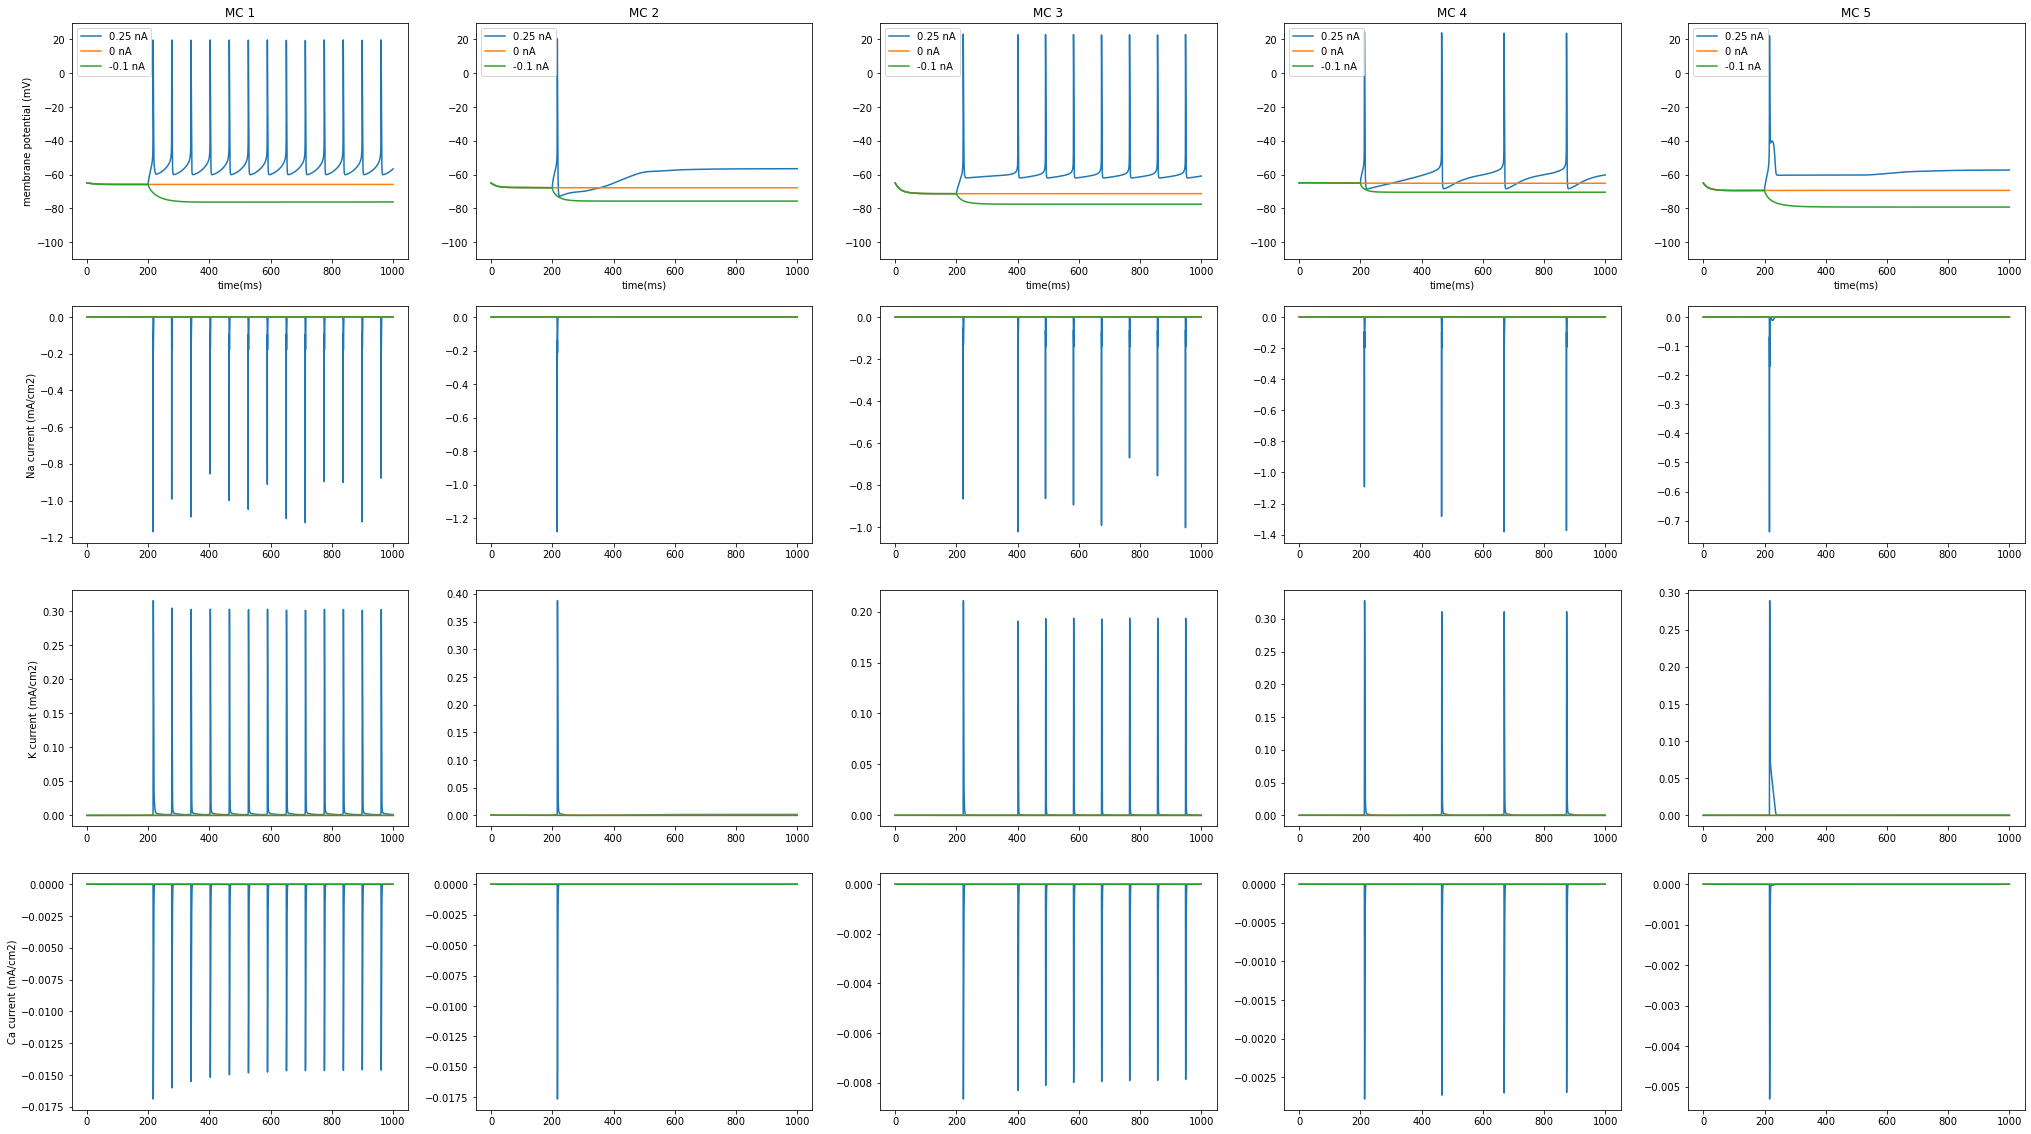

In [9]:
fig, axs = plt.subplots(4, num_mc_cells, figsize=(35,20), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(mc_cells):
    for amp in mc_amps:
        t, v, iNa, iK, iCa = add_background_input(cell, amp)

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_mc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_mc_cells].plot(t, iK, label=f'{amp} nA')
        axs[idx+3*num_mc_cells].plot(t, iCa, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')
axs[15].set_ylabel('Ca current (mA/cm2)')

## Tufted Cells

In [16]:
#tc_amps = [0.25, 0, -0.1]
tc_amps = background_current_values

num_tc_cells = len(tc_cells)

Text(0, 0.5, 'Ca current (mA/cm2)')

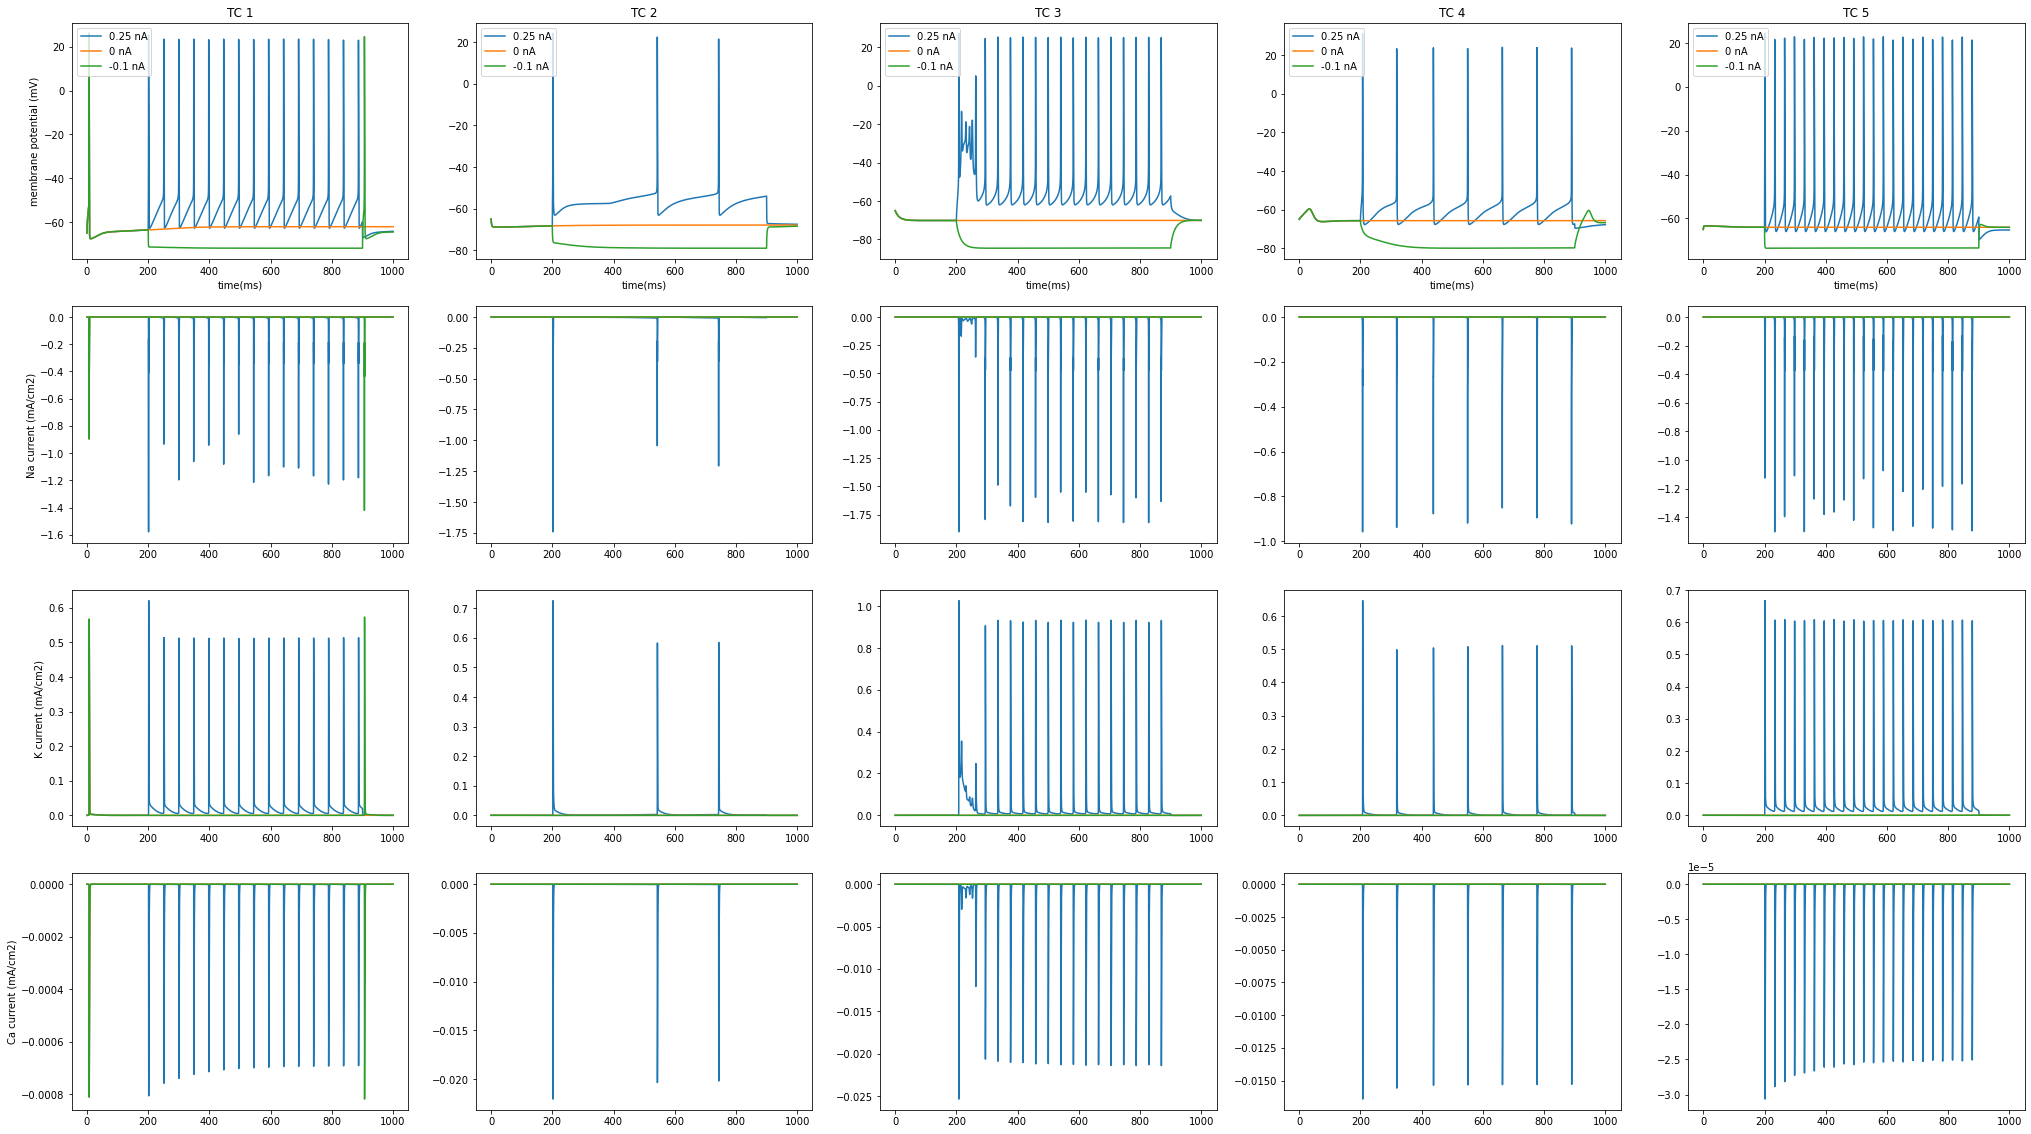

In [17]:
fig, axs = plt.subplots(4, num_tc_cells, figsize=(35,20), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(tc_cells):
    for amp in tc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)
        iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
        iK = h.Vector().record(cell.soma(0.5)._ref_ik)
        iCa = h.Vector().record(cell.soma(0.5)._ref_ica)
        
        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_tc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_tc_cells].plot(t, iK, label=f'{amp} nA')
        axs[idx+3*num_tc_cells].plot(t, iCa, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')
axs[15].set_ylabel('Ca current (mA/cm2)')

## Granule Cells

In [18]:
#gc_amps = [0.06, 0, -0.02]
gc_amps = background_current_values

num_gc_cells = len(gc_cells)

Text(0, 0.5, 'K current (mA/cm2)')

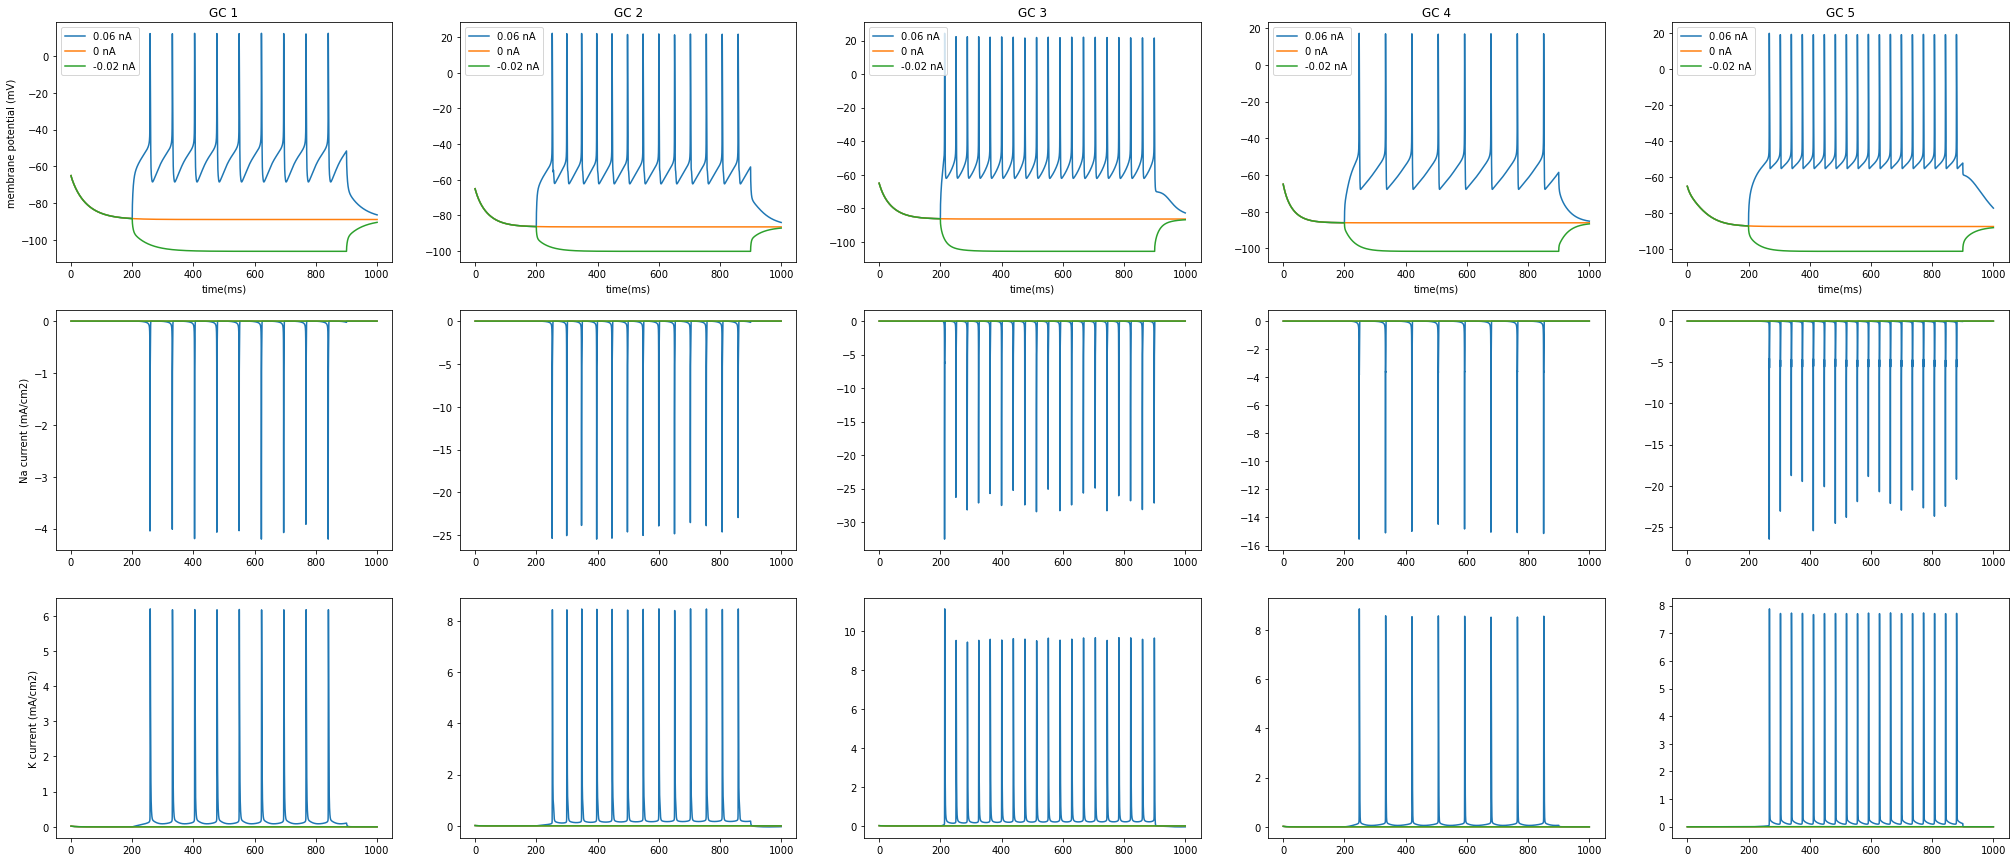

In [19]:
fig, axs = plt.subplots(3, num_gc_cells, figsize=(35,15), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)
        iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
        iK = h.Vector().record(cell.soma(0.5)._ref_ik)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_gc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_gc_cells].plot(t, iK, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')

In [14]:
gc_amps = [0.06, 0, -0.02]
gc_cells = [gc_cell]
num_gc_cells = len(gc_cells)

NameError: name 'gc_cell' is not defined

Text(0, 0.5, 'membrane potential (mV)')

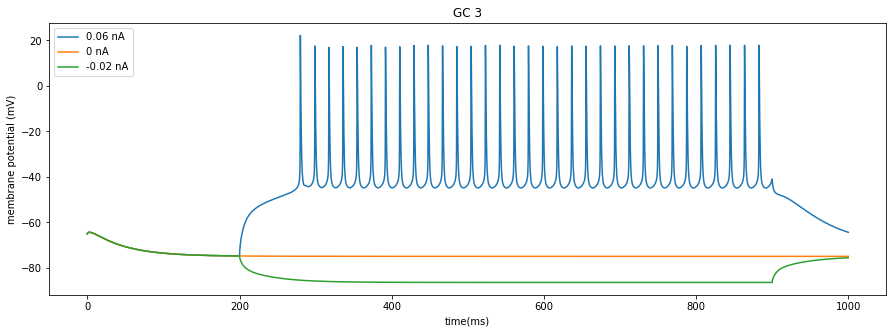

In [ ]:
fig, axs = plt.subplots(1, num_gc_cells, figsize=(15,5), sharey=True)
# axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs.plot(t, v, label=f'{amp} nA')
    
    axs.set_title(f'{cell.cell_type} {cell.cell_id}')

    axs.legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs.set_xlabel('time(ms)')

axs.set_ylabel('membrane potential (mV)')